<a href="https://colab.research.google.com/github/palak-singh1181/Palak-First/blob/main/Week_4_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [3]:
# CIFAR-10 has 60000 images, 10 classes
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


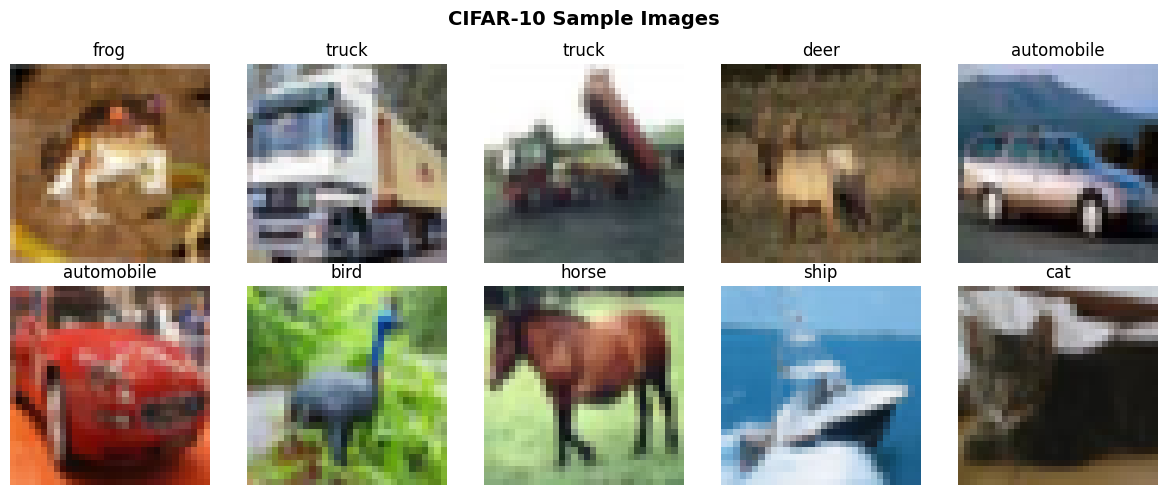

In [4]:
# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_train[i])
    axes[i].set_title(class_names[y_train[i][0]])
    axes[i].axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

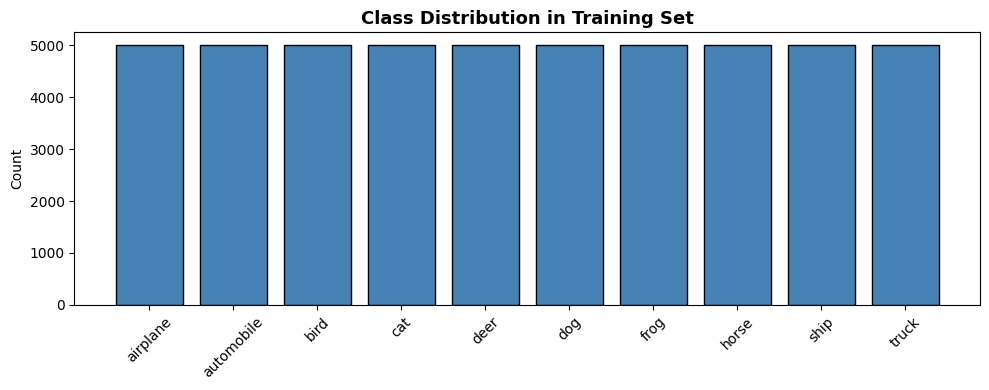

In [5]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Normalize pixel values 0-255 to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("X_train range:", X_train.min(), "-", X_train.max())
print("y_train_cat shape:", y_train_cat.shape)

X_train range: 0.0 - 1.0
y_train_cat shape: (50000, 10)


In [7]:
# Flatten input for ANN
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # 50000 x 3072
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened shape:", X_train_flat.shape)

Flattened shape: (50000, 3072)


In [8]:
# Build ANN Model
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,811,594 (14.54 MB)

 Trainable params: 3,808,522 (14.53 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [9]:
# Train ANN
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

ann_history = ann_model.fit(
    X_train_flat, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3217 - loss: 1.9603 - val_accuracy: 0.3436 - val_loss: 1.8172
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3891 - loss: 1.6985 - val_accuracy: 0.3826 - val_loss: 1.7057
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4115 - loss: 1.6419 - val_accuracy: 0.3980 - val_loss: 1.6918
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4170 - loss: 1.6309 - val_accuracy: 0.3936 - val_loss: 1.6970
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4266 - loss: 1.6079 - val_accuracy: 0.4470 - val_loss: 1.5365
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4360 - loss: 1.5818 - val_accuracy: 0.3962 - val_loss: 1.7088
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4378 - loss: 1.5747 - val_accuracy: 0.3828 - val_loss: 1.7227
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4447 - loss: 1.5566 - val_accuracy: 0

In [10]:
# Build CNN Model
cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,194,538 (4.56 MB)

 Trainable params: 1,194,090 (4.56 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# Train CNN
cnn_history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.3944 - loss: 1.7156 - val_accuracy: 0.4488 - val_loss: 1.5585
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5361 - loss: 1.2860 - val_accuracy: 0.6218 - val_loss: 1.0587
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6109 - loss: 1.1080 - val_accuracy: 0.6498 - val_loss: 1.0309
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6582 - loss: 0.9731 - val_accuracy: 0.6712 - val_loss: 1.0562
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6909 - loss: 0.8911 - val_accuracy: 0.7278 - val_loss: 0.7937
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7151 - loss: 0.8223 - val_accuracy: 0.7748 - val_loss: 0.6683
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7352 - loss: 0.7665 - val_accuracy: 0.7522 - val_loss: 0.7198
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7495 - loss: 0.7226 - val_accuracy: 

In [12]:
# Evaluate CNN
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc*100:.2f}%")
print(f"CNN Test Loss: {cnn_loss:.4f}")

CNN Test Accuracy: 82.92%
CNN Test Loss: 0.5459


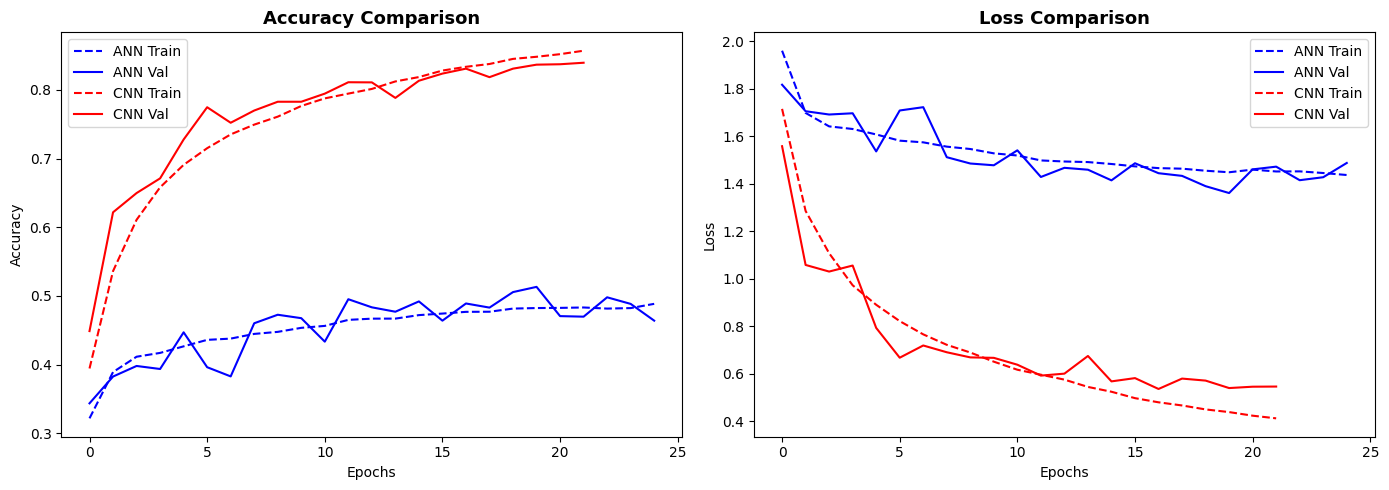

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(ann_history.history['accuracy'], label='ANN Train', color='blue', linestyle='--')
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val', color='blue')
axes[0].plot(cnn_history.history['accuracy'], label='CNN Train', color='red', linestyle='--')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val', color='red')
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(ann_history.history['loss'], label='ANN Train', color='blue', linestyle='--')
axes[1].plot(ann_history.history['val_loss'], label='ANN Val', color='blue')
axes[1].plot(cnn_history.history['loss'], label='CNN Train', color='red', linestyle='--')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val', color='red')
axes[1].set_title('Loss Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step


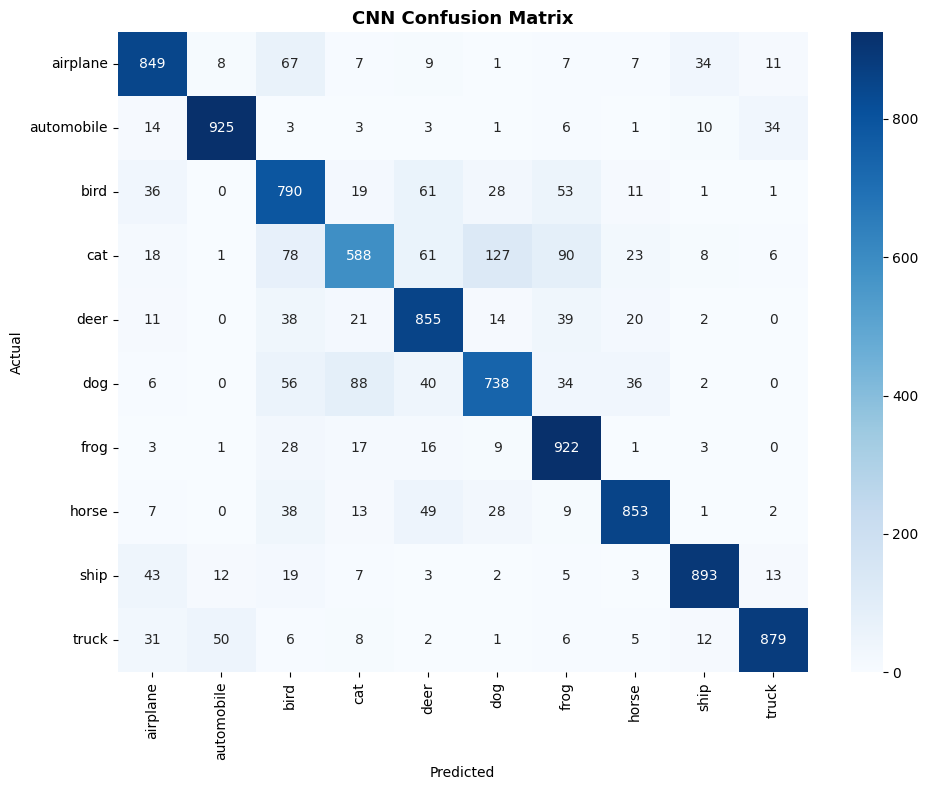

In [14]:
# CNN Confusion Matrix
y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [15]:
# Classification Report
print("CNN Classification Report:")
print(classification_report(y_true, y_pred_cnn, target_names=class_names))

CNN Classification Report:
              precision    recall  f1-score   support

    airplane       0.83      0.85      0.84      1000
  automobile       0.93      0.93      0.93      1000
        bird       0.70      0.79      0.74      1000
         cat       0.76      0.59      0.66      1000
        deer       0.78      0.85      0.81      1000
         dog       0.78      0.74      0.76      1000
        frog       0.79      0.92      0.85      1000
       horse       0.89      0.85      0.87      1000
        ship       0.92      0.89      0.91      1000
       truck       0.93      0.88      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



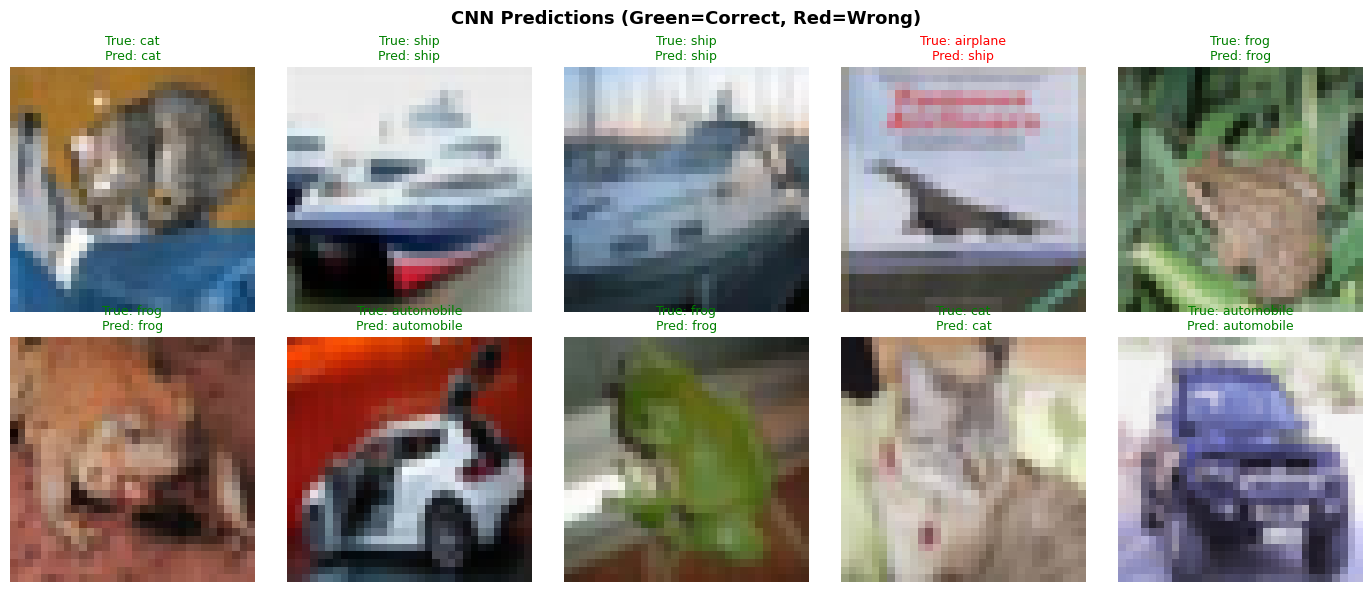

In [16]:
# Show sample predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_test[i])
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred_cnn[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('CNN Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
print("="*45)
print("       MODEL COMPARISON SUMMARY")
print("="*45)
print(f"{'Model':<15} {'Accuracy':>10} {'Loss':>10}")
print("-"*45)
print(f"{'ANN':<15} {ann_acc*100:>9.2f}% {ann_loss:>10.4f}")
print(f"{'CNN':<15} {cnn_acc*100:>9.2f}% {cnn_loss:>10.4f}")
print("="*45)

models_list = ['ANN', 'CNN']
accuracies = [ann_acc*100, cnn_acc*100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models_list, accuracies, color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)
plt.title('ANN vs CNN - Test Accuracy', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

       MODEL COMPARISON SUMMARY
Model             Accuracy       Loss
---------------------------------------------


NameError: name 'ann_acc' is not defined

In [18]:
# Evaluate ANN
ann_loss, ann_acc = ann_model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"ANN Test Accuracy: {ann_acc*100:.2f}%")
print(f"ANN Test Loss: {ann_loss:.4f}")

ANN Test Accuracy: 50.97%
ANN Test Loss: 1.3787
